# Montar guardado de csv en drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Correr ollama en la nube

In [ ]:
# 1. Instalar la dependencia de Linux que falta (zstd)
!apt-get update -qq && apt-get install -y -qq zstd

# 2. Instalar Ollama silenciosamente
!curl -fsSL https://ollama.com/install.sh | sh

# 3. Levantar el servidor de Ollama en segundo plano
import subprocess
import time
print("Iniciando servidor de Ollama...")
subprocess.Popen(["ollama", "serve"])
time.sleep(3) # Damos 3 segundos para que arranque

# 4. Descargar Gemma 2 9B directo a la GPU
print("Descargando el modelo Gemma 2 9B (esto tomará unos minutos)...")
!ollama pull gemma2:9b

# 5. Instalar las librerias de Python necesarias
!pip install -q ollama datasets
print("¡Entorno listo!")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Iniciando servidor de Ollama...
Descargando el modelo Gemma 2 9B (esto tomará u

# Importacion dependencias y configuracion

In [ ]:
import pandas as pd
import ollama
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Configuracion visual para las graficas
sns.set_theme(style="whitegrid")

MMLU_CATEGORIAS = {
    "college_computer_science": 1,
    "computer_security": 2,
    "machine_learning": 3
}

# Funcion de traduccion robusta

In [ ]:
def traducir_y_formatear(pregunta_eng, opciones_eng, respuesta_idx):
    letras = ["A", "B", "C", "D"]
    respuesta_letra = letras[respuesta_idx]

    prompt = f"""
    Eres un traductor tecnico experto en Ingenieria en Computacion.
    Traduce esta pregunta de opcion multiple del ingles al espanol tecnico de Mexico.

    Pregunta original: {pregunta_eng}
    Opciones:
    A) {opciones_eng[0]}
    B) {opciones_eng[1]}
    C) {opciones_eng[2]}
    D) {opciones_eng[3]}

    RESPONDE EXCLUSIVAMENTE CON UN JSON VALIDO. Sigue exactamente esta estructura:
    {{
        "contexto_practico": "La pregunta traducida de forma clara.",
        "opcion_a": "Traduccion de A",
        "opcion_b": "Traduccion de B",
        "opcion_c": "Traduccion de C",
        "opcion_d": "Traduccion de D",
        "respuesta_correcta": "{respuesta_letra}",
        "justificacion": "Genera una breve explicacion tecnica en espanol de por que la {respuesta_letra} es correcta."
    }}
    """

    try:
        response = ollama.chat(model="gemma2:9b", messages=[
            {'role': 'system', 'content': 'You output strictly valid JSON dictionaries.'},
            {'role': 'user', 'content': prompt},
        ])

        content = response['message']['content']

        if "```json" in content:
            content = content.split("```json")[1].split("```")[0]
        elif "```" in content:
            content = content.split("```")[1].split("```")[0]

        return json.loads(content.strip())
    except Exception as e:
        print(f"[ERROR] Fallo en la traduccion o parseo JSON: {e}")
        return None

# Ingesta de datos

In [ ]:
nuevas_filas = []
print("Iniciando el pipeline de extraccion y traduccion en Colab con GPU (Modo Completo)...")

# Definimos la ruta directamente aqui para evitar errores de nombres entre celdas
RUTA_DRIVE = "/content/drive/MyDrive/dataset_mmlu_traducido_final.csv"

for categoria, etiqueta in MMLU_CATEGORIAS.items():
    print(f"\nProcesando TODA la categoria: {categoria}")
    # Usamos test+validation+dev para extraer el 100% de los datos
    dataset = load_dataset("cais/mmlu", categoria, split="test+validation+dev")
    total_preguntas = len(dataset)

    for i, item in enumerate(dataset):
        # Monitoreo silencioso y autoguardado
        if (i+1) % 10 == 0:
            print(f"  -> Traduciendo reactivo [{i+1}/{total_preguntas}] de {categoria}...")
            pd.DataFrame(nuevas_filas).to_csv(RUTA_DRIVE, index=False)

        resultado = traducir_y_formatear(item['question'], item['choices'], item['answer'])

        if resultado:
            texto_combinado = f"{resultado.get('contexto_practico', '')}\nA) {resultado.get('opcion_a', '')}\nB) {resultado.get('opcion_b', '')}\nC) {resultado.get('opcion_c', '')}\nD) {resultado.get('opcion_d', '')}"
            respuesta_combinada = f"Respuesta: {resultado.get('respuesta_correcta', '')} - {resultado.get('justificacion', '')}"

            nuevas_filas.append({
                "texto": texto_combinado,
                "respuesta": respuesta_combinada,
                "etiqueta": etiqueta,
                "area_origen": f"MMLU_{categoria}"
            })

# Guardado final definitivo
df_mmlu = pd.DataFrame(nuevas_filas)
df_mmlu.to_csv(RUTA_DRIVE, index=False, encoding='utf-8')

print(f"\nProceso finalizado exitosamente. Total de reactivos generados: {len(df_mmlu)}")
print(f"El archivo se guardo en tu Google Drive como '{RUTA_DRIVE}'.")

Iniciando el pipeline de extraccion y traduccion en Colab con GPU (Modo Completo)...

Procesando TODA la categoria: college_computer_science
  -> Traduciendo reactivo [10/116] de college_computer_science...
  -> Traduciendo reactivo [20/116] de college_computer_science...
  -> Traduciendo reactivo [30/116] de college_computer_science...
  -> Traduciendo reactivo [40/116] de college_computer_science...
  -> Traduciendo reactivo [50/116] de college_computer_science...
  -> Traduciendo reactivo [60/116] de college_computer_science...
  -> Traduciendo reactivo [70/116] de college_computer_science...
  -> Traduciendo reactivo [80/116] de college_computer_science...
  -> Traduciendo reactivo [90/116] de college_computer_science...
  -> Traduciendo reactivo [100/116] de college_computer_science...
  -> Traduciendo reactivo [110/116] de college_computer_science...

Procesando TODA la categoria: computer_security


computer_security/test-00000-of-00001.pa(…):   0%|          | 0.00/19.1k [00:00<?, ?B/s]

computer_security/validation-00000-of-00(…):   0%|          | 0.00/6.67k [00:00<?, ?B/s]

computer_security/dev-00000-of-00001.par(…):   0%|          | 0.00/4.33k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

...

machine_learning/dev-00000-of-00001.parq(…):   0%|          | 0.00/5.25k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/112 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/5 [00:00<?, ? examples/s]

  -> Traduciendo reactivo [10/128] de machine_learning...
  -> Traduciendo reactivo [20/128] de machine_learning...
  -> Traduciendo reactivo [30/128] de machine_learning...
  -> Traduciendo reactivo [40/128] de machine_learning...
  -> Traduciendo reactivo [50/128] de machine_learning...
  -> Traduciendo reactivo [60/128] de machine_learning...
  -> Traduciendo reactivo [70/128] de machine_learning...
  -> Traduciendo reactivo [80/128] de machine_learning...
  -> Traduciendo reactivo [90/128] de machine_learning...
  -> Traduciendo reactivo [100/128] de machine_learning...
[ERROR] Fallo en la traduccion o parseo JSON: Invalid \escape: line 2 column 205 (char 206)
[ERROR] Fallo en la traduccion o parseo JSON: Invalid \escape: line 2 column 83 (char 84)
  -> Traduciendo reactivo [110/128] de machine_learning...
[ERROR] Fallo en la traduccion o parseo JSON: Invalid \escape: line 4 column 31 (char 270)
[ERROR] Fallo en la traduccion o parseo JSON: Invalid \escape: line 2 column 120 (char 

/tmp/ipykernel_6236/579436236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_mmlu, x='area_origen', order=df_mmlu['area_origen'].value_counts().index, palette='viridis')


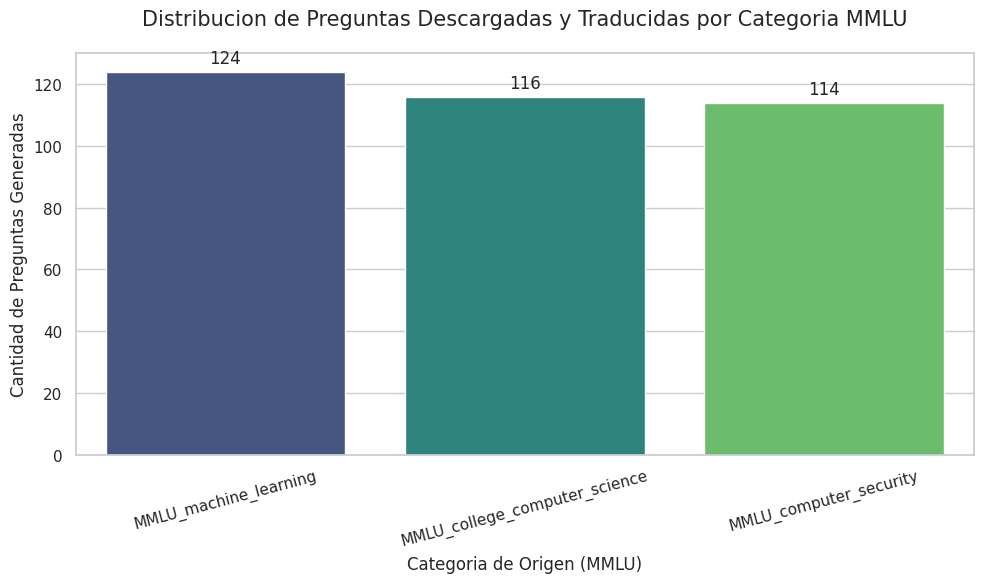


--- Resumen Estadístico de las Categorías ---


,area_origen,Total
2,MMLU_machine_learning,124
0,MMLU_college_computer_science,116
1,MMLU_computer_security,114



Vista previa de los primeros 5 registros generados:


,texto,respuesta,etiqueta,area_origen
0,El enfoque basado en matrices de acceso presen...,Respuesta: A - La opción A es correcta porque ...,1,MMLU_college_computer_science
1,Un entero *c* es un divisor común de dos enter...,Respuesta: C - La opción C es correcta porque ...,1,MMLU_college_computer_science
2,"En el sistema operativo NoNicks, el tiempo req...","Respuesta: B - La opción B es correcta porque,...",1,MMLU_college_computer_science
3,Se desea agrupar 7 puntos en 3 clusters utiliz...,Respuesta: A - La respuesta correcta es la opc...,1,MMLU_college_computer_science
4,Un conjunto de operadores booleanos que sea su...,"Respuesta: C - La opción C, {Y, O}, no es comp...",1,MMLU_college_computer_science


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual para las graficas (estilo profesional)
sns.set_theme(style="whitegrid")

# Grafica 1: Grafico de Barras (Count plot) para ver la distribucion de categorias
# Esta es la opcion ideal para EDA de distribuciones categoricas
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_mmlu, x='area_origen', order=df_mmlu['area_origen'].value_counts().index, palette='viridis')

# Personalizacion profesional
plt.title('Distribucion de Preguntas Descargadas y Traducidas por Categoria MMLU', fontsize=15, pad=20)
plt.xlabel('Categoria de Origen (MMLU)', fontsize=12)
plt.ylabel('Cantidad de Preguntas Generadas', fontsize=12)
plt.xticks(rotation=15) # Rotar etiquetas para que no se encimen

# Agregar etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

# Resumen Estadístico para confirmación rapida
print("\n--- Resumen Estadístico de las Categorías ---")
display(df_mmlu.groupby('area_origen').size().reset_index(name='Total').sort_values('Total', ascending=False))

# EDA Step 2 (Opcional pero recomendado): Vista previa de calidad
print("\nVista previa de los primeros 5 registros generados:")
display(df_mmlu.head())